In [6]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np

import iddefix

from scipy.constants import c as c_light

from iddefix.poleResidueFitting import (
    build_fit_weights,
    fit_poles_evolutionary,
)

from iddefix.poleResidueFormulas import (
    PoleResidue,
)

### Import data & visualization

In [7]:
data_path = (
    Path.cwd()
    / "data"
    / "004_SPS_model_transitions_q26.txt"
)

print(data_path)

data = np.loadtxt(
    data_path,
    comments="#",
    delimiter="\t",
)

wake_time = (
    data[:, 0]
    * 1.0e-9
)

dipolar_wake_potential = data[:, 2]

print(
    f"Number of wake samples: "
    f"{wake_time.size}"
)

print(
    f"Time interval: "
    f"{wake_time[0] * 1e9:.3f} ns "
    f"to {wake_time[-1] * 1e9:.3f} ns"
)

/home/hschreib/Documents/Iddefix/IDDEFIX/examples/data/004_SPS_model_transitions_q26.txt
Number of wake samples: 25636
Time interval: -0.427 ns to 16.663 ns


In [8]:
frequencies, wake_transform = (
    iddefix.compute_fft(
        wake_time,
        dipolar_wake_potential,
    )
)

transverse_impedance = (
    -1j * wake_transform
)

wake_length = (
    wake_time[-1]
    * c_light
)

print(
    f"Wake length: "
    f"{wake_length:.3f} m"
)

Wake length: 4.996 m


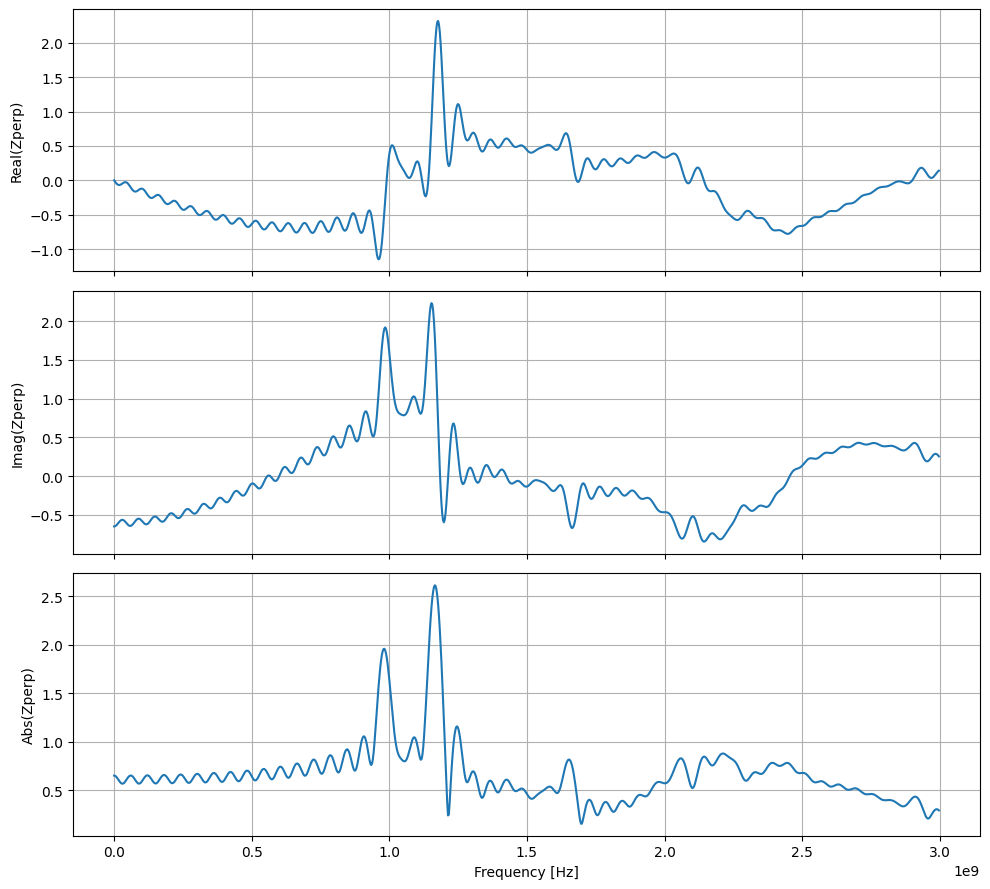

In [9]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(10, 9),
    sharex=True,
)

axes[0].plot(
    frequencies,
    transverse_impedance.real,
)

axes[1].plot(
    frequencies,
    transverse_impedance.imag,
)

axes[2].plot(
    frequencies,
    np.abs(transverse_impedance),
)

axes[0].set_ylabel("Real(Zperp)")
axes[1].set_ylabel("Imag(Zperp)")
axes[2].set_ylabel("Abs(Zperp)")
axes[2].set_xlabel("Frequency [Hz]")

for axis in axes:
    axis.grid()

plt.tight_layout()
plt.show()

Detected resonances: 9
Resonance frequencies [GHz]:
[0.98198395 1.1651675  1.24624874 1.65465797 2.05706118 2.14414844
 2.21021464 2.44745235 2.91291874]


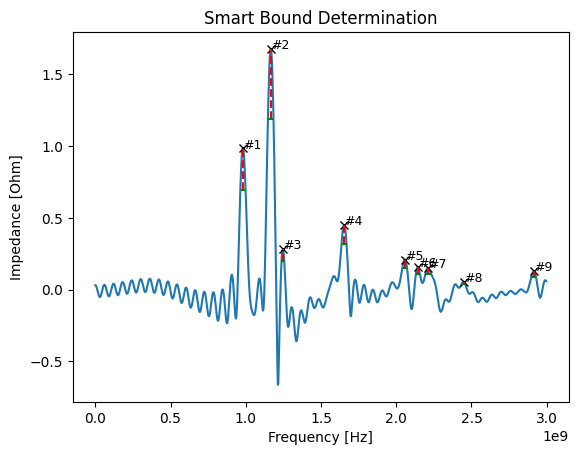


--------------------------------------------------------------------------------
Resonator |   Rs [Ohm/m or Ohm]    |        Q         |        fres [Hz]        
--------------------------------------------------------------------------------
    1     |      0.79 to 9.84      | 16.35 to 163.50  |  9.72e+08 to 9.92e+08   
    2     |     1.34 to 16.76      | 16.17 to 161.67  |  1.16e+09 to 1.18e+09   
    3     |      0.23 to 2.83      | 34.58 to 345.83  |  1.24e+09 to 1.26e+09   
    4     |      0.36 to 4.49      | 27.55 to 275.50  |  1.64e+09 to 1.66e+09   
    5     |      0.17 to 2.10      | 34.25 to 342.50  |  2.05e+09 to 2.07e+09   
    6     |      0.13 to 1.57      | 44.63 to 446.25  |  2.13e+09 to 2.15e+09   
    7     |      0.12 to 1.51      | 30.67 to 306.67  |  2.20e+09 to 2.22e+09   
    8     |      0.04 to 0.55      | 67.92 to 679.17  |  2.44e+09 to 2.46e+09   
    9     |      0.10 to 1.29      | 48.50 to 485.00  |  2.90e+09 to 2.92e+09   
---------------------------

In [10]:
early_wake = np.where(
    wake_time <= 1.0e-9,
    dipolar_wake_potential,
    0.0,
)

_, early_wake_transform = (
    iddefix.compute_fft(
        wake_time,
        early_wake,
    )
)

detection_signal = (
    np.abs(wake_transform)
    - np.abs(early_wake_transform)
)

minimum_peak_heights = np.zeros_like(
    frequencies
)

minimum_peak_heights[
    frequencies < 2.0e9
] = 0.25

minimum_peak_heights[
    frequencies >= 2.0e9
] = 0.05

minimum_peak_heights[
    frequencies >= 2.5e9
] = 0.10

smart_bounds = (
    iddefix.SmartBoundDetermination(
        frequency_data=frequencies,
        impedance_data=detection_signal,
        minimum_peak_height=(
            minimum_peak_heights
        ),
    )
)

number_complex_pairs = int(
    smart_bounds.N_resonators
)

print(
    f"Detected resonances: "
    f"{number_complex_pairs}"
)

print(
    "Resonance frequencies [GHz]:"
)

print(
    frequencies[smart_bounds.peaks]
    / 1.0e9
)

smart_bounds.inspect()
smart_bounds.to_table()

In [11]:
background_indices = np.linspace(
    0,
    frequencies.size - 1,
    150,
    dtype=int,
)

selected_indices = [
    background_indices
]

for resonance_index, peak_index in enumerate(
    smart_bounds.peaks
):
    peak_frequency = frequencies[
        peak_index
    ]

    resonance_width = (
        smart_bounds.upper_lower_bounds[
            resonance_index
        ]
    )

    inside_window = np.flatnonzero(
        np.abs(
            frequencies
            - peak_frequency
        )
        <= 2.0 * resonance_width
    )

    if inside_window.size > 25:
        local_selection = np.linspace(
            0,
            inside_window.size - 1,
            25,
            dtype=int,
        )

        inside_window = (
            inside_window[
                local_selection
            ]
        )

    selected_indices.append(
        inside_window
    )

    selected_indices.append(
        np.asarray(
            [peak_index]
        )
    )

fit_indices = np.unique(
    np.concatenate(
        selected_indices
    )
)

fit_frequencies = frequencies[
    fit_indices
]

fit_impedance = transverse_impedance[
    fit_indices
]

print(
    f"Using {fit_indices.size} "
    f"of {frequencies.size} points"
)

Using 297 of 999 points


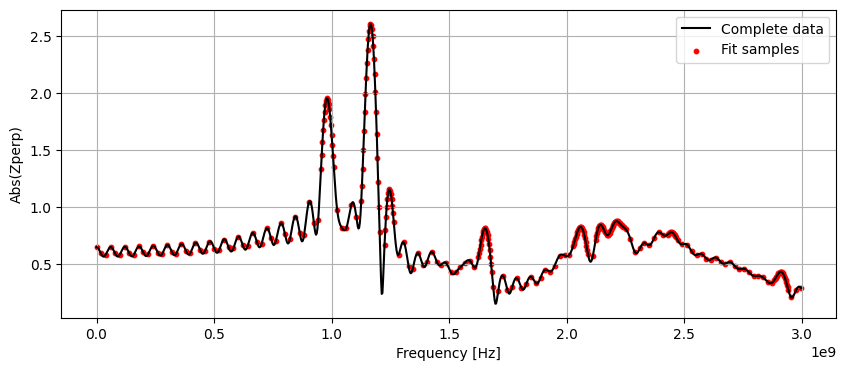

In [12]:
plt.figure(figsize=(10, 4))

plt.plot(
    frequencies,
    np.abs(transverse_impedance),
    color="black",
    label="Complete data",
)

plt.scatter(
    fit_frequencies,
    np.abs(fit_impedance),
    s=10,
    color="red",
    label="Fit samples",
)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Abs(Zperp)")
plt.grid()
plt.legend()
plt.show()

In [13]:
def weighted_complex_error(
    parameters,
    fitFunction,
    x,
    y,
):
    fitted = fitFunction(
        x,
        parameters,
    )

    weights = build_fit_weights(
        frequencies=x,
        impedance=y,
        amplitude_weighting=(
            "sqrt_relative"
        ),
        frequency_weighting="linear",
    )

    return float(
        np.sum(
            np.abs(
                weights * (fitted - y)
            ) ** 2
        )
    )

In [24]:
np.random.seed(2026)

resonator_model = (
    iddefix.EvolutionaryAlgorithm(
        x_data=frequencies,
        y_data=transverse_impedance,
        N_resonators=(
            number_complex_pairs
        ),
        parameterBounds=(
            smart_bounds.parameterBounds
        ),
        plane="transverse",
        wake_length=wake_length,
        objectiveFunction=iddefix.ObjectiveFunctions.sumOfSquaredErrorReal,
    )
)

start_time = perf_counter()

resonator_model.run_differential_evolution(
    maxiter=200,
    popsize=180,
    tol=1.0e-4,
    mutation=(0.1, 0.5),
    crossover_rate=0.8,
    solver="scipy",
)

resonator_runtime = (
    perf_counter()
    - start_time
)

resonator_impedance = (
    resonator_model
    .get_impedance_from_fitFunction(
        frequency_data=frequencies,
        use_minimization=False,
    )
)

print(
    f"Runtime: "
    f"{resonator_runtime:.2f} s"
)

[!] Using the partially decayed resonator formalism for impedance


Differential Evolution: 100%|██████████| 200/200 [03:18<00:00,  1.01gen/s, conv=28.0 %]

[!] Warning: 15 parameter(s) have relative uncertainty >= 0.20 (max 213.80).


----------------------------------------------------------------------------
Resonator |   Rs [Ohm/m or Ohm]    |        Q         |       fres [Hz]        
----------------------------------------------------------------------------
    1     |   8.13e-01 ± 3.3e+00   | 158.19 ± 742.78  |   9.92e+08 ± 8.0e+06   
    2     |   3.55e+00 ± 5.6e-01   |  67.99 ± 15.77   |   1.18e+09 ± 9.9e+05   
    3     |   1.26e+00 ± 1.8e-01   |   34.63 ± 8.43   |   1.26e+09 ± 2.5e+06   
    4     |   7.76e-01 ± 1.2e-01   |   27.61 ± 5.91   |   1.64e+09 ± 4.4e+06   
    5     |   3.96e-01 ± 1.2e-01   |  36.21 ± 18.61   |   2.05e+09 ± 8.7e+06   
    6     |   1.73e-01 ± 7.0e+00   |384.19 ± 17835.32 |   2.14e+09 ± 4.5e+07   
    7     |   1.24e-01 ± 3.3e+00   | 287.36 ± 9244.08 |   2.20e+09 ± 5.0e+07   
    8     |   4.84e-02 ± 9.4e+00   |661.70 ± 141468.59|   2.45e+09 ± 2.1e+08   
    9     |   4.73e-01 ± 1.4e+00   | 297.54 ± 1

In [18]:
def smart_bounds_to_complex_pole_bounds(
    parameter_bounds,
):
    """Convert (Q, fres) bounds to (alpha, beta) bounds.

    The complex pole in the upper half-plane is

        p = -alpha + 1j * beta

    with

        alpha = omega_r / (2 Q)

        beta = omega_r * sqrt(
            1 - 1 / (4 Q**2)
        )
    """
    decay_bounds = []
    frequency_bounds = []

    for index in range(
        0,
        len(parameter_bounds),
        3,
    ):
        q_min, q_max = (
            parameter_bounds[index + 1]
        )

        f_min, f_max = (
            parameter_bounds[index + 2]
        )

        # Complex poles require Q > 1/2.
        q_min = max(
            q_min,
            0.5 + 1.0e-12,
        )

        q_max = max(
            q_max,
            q_min,
        )

        f_min = max(
            f_min,
            np.finfo(float).tiny,
        )

        f_max = max(
            f_max,
            f_min,
        )

        omega_min = (
            2.0
            * np.pi
            * f_min
        )

        omega_max = (
            2.0
            * np.pi
            * f_max
        )

        alpha_min = (
            omega_min
            / (2.0 * q_max)
        )

        alpha_max = (
            omega_max
            / (2.0 * q_min)
        )

        beta_min = (
            omega_min
            * np.sqrt(
                1.0
                - 1.0 / (4.0 * q_min**2)
            )
        )

        beta_max = (
            omega_max
            * np.sqrt(
                1.0
                - 1.0 / (4.0 * q_max**2)
            )
        )

        decay_bounds.append(
            (
                np.log10(alpha_min),
                np.log10(alpha_max),
            )
        )

        frequency_bounds.append(
            (
                np.log10(beta_min),
                np.log10(beta_max),
            )
        )

    # Parameter order expected by decode_log_poles:
    #
    # [
    #   all complex decay rates,
    #   all complex angular frequencies,
    # ]
    return (
        decay_bounds
        + frequency_bounds
    )

In [19]:
complex_pole_bounds = (
    smart_bounds_to_complex_pole_bounds(
        smart_bounds.parameterBounds
    )
)

print(
    f"Number of complex pairs: "
    f"{number_complex_pairs}"
)

print(
    f"Number of pole bounds: "
    f"{len(complex_pole_bounds)}"
)

assert len(complex_pole_bounds) == (
    2 * number_complex_pairs
)

Number of complex pairs: 9
Number of pole bounds: 18


In [12]:
wake = DE_model.get_wake(data_wake_time)
wake.shape

(25636,)

In [20]:
start_time = perf_counter()

pole_result_complex_only = (
    fit_poles_evolutionary(
        frequencies=fit_frequencies,
        impedance=fit_impedance,
        number_real_poles=0,
        number_complex_pairs=(
            number_complex_pairs
        ),
        parameter_bounds=(
            complex_pole_bounds
        ),
        wake_length=wake_length,
        plane="transverse",
        fit_direct_term=False,
        enforce_zero_dc=False,
        amplitude_weighting=(
            "sqrt_relative"
        ),
        frequency_weighting="linear",
        maxiter=200,
        popsize=10,
        mutation=(0.1, 0.5),
        crossover_rate=0.8,
        tol=1.0e-4,
        polish=True,
        seed=2026,
        workers=1,
    )
)

pole_runtime_complex_only = (
    perf_counter()
    - start_time
)

print(
    f"Runtime: "
    f"{pole_runtime_complex_only:.2f} s"
)

print(
    "Objective value: "
    f"{pole_result_complex_only.objective_value:.6e}"
)

print(
    "Complex poles:"
)

print(
    pole_result_complex_only.complex_poles
)

Runtime: 235.72 s
Objective value: 2.898065e-01
Complex poles:
[-1.90606085e+08+6.17199339e+09j -1.03932000e+08+7.28590492e+09j
 -1.14119185e+08+7.76676806e+09j -6.37897441e+07+1.04483410e+10j
 -1.89601875e+08+1.29877146e+10j -1.51651695e+08+1.35349053e+10j
 -2.27445978e+08+1.39500014e+10j -1.13673339e+08+1.53145497e+10j
 -1.89332372e+08+1.82545233e+10j]


In [21]:
pole_impedance_complex_only = (
    PoleResidue.finite_wake_impedance(
        frequencies=frequencies,
        poles=(
            pole_result_complex_only
            .residue_fit
            .poles
        ),
        residues=(
            pole_result_complex_only
            .residue_fit
            .residues
        ),
        direct_term=(
            pole_result_complex_only
            .residue_fit
            .direct_term
        ),
        wake_length=wake_length,
        plane="transverse",
    )
)

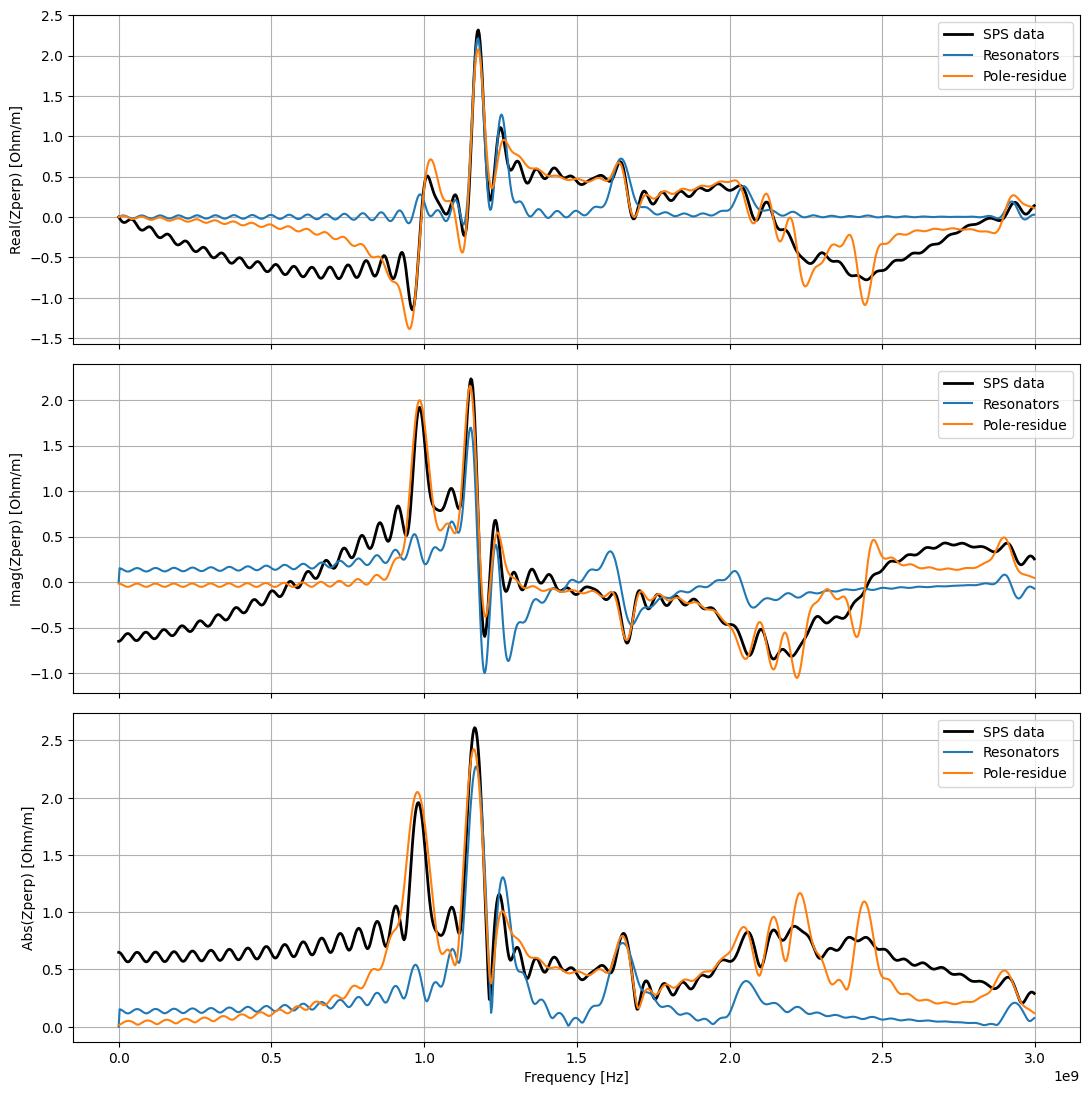

In [25]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(11, 11),
    sharex=True,
)

axes[0].plot(
    frequencies,
    transverse_impedance.real,
    color="black",
    linewidth=2,
    label="SPS data",
)

axes[0].plot(
    frequencies,
    resonator_impedance.real,
    label="Resonators",
)

axes[0].plot(
    frequencies,
    pole_impedance_complex_only.real,
    label="Pole-residue",
)

axes[1].plot(
    frequencies,
    transverse_impedance.imag,
    color="black",
    linewidth=2,
    label="SPS data",
)

axes[1].plot(
    frequencies,
    resonator_impedance.imag,
    label="Resonators",
)

axes[1].plot(
    frequencies,
    pole_impedance_complex_only.imag,
    label="Pole-residue",
)

axes[2].plot(
    frequencies,
    np.abs(transverse_impedance),
    color="black",
    linewidth=2,
    label="SPS data",
)

axes[2].plot(
    frequencies,
    np.abs(resonator_impedance),
    label="Resonators",
)

axes[2].plot(
    frequencies,
    np.abs(pole_impedance_complex_only),
    label="Pole-residue",
)

axes[0].set_ylabel(
    "Real(Zperp) [Ohm/m]"
)

axes[1].set_ylabel(
    "Imag(Zperp) [Ohm/m]"
)

axes[2].set_ylabel(
    "Abs(Zperp) [Ohm/m]"
)

axes[2].set_xlabel(
    "Frequency [Hz]"
)

for axis in axes:
    axis.grid()
    axis.legend()

plt.tight_layout()
plt.show()

<>:32: SyntaxWarning: invalid escape sequence '\O'
<>:32: SyntaxWarning: invalid escape sequence '\O'
/tmp/hschreib/ipykernel_230758/3299331348.py:32: SyntaxWarning: invalid escape sequence '\O'
  ax0.set_ylabel("$[ABS](Z_{transverse})$ [$\Omega$]")


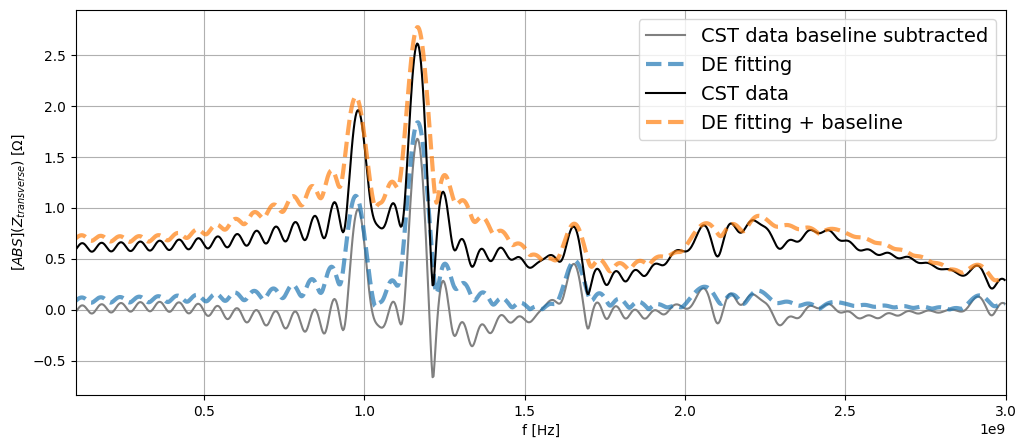

In [13]:
# Plot real part of impedance
fig, ax0 = plt.subplots(1, 1, figsize=(12, 5))

ax0.plot(
    DE_model.frequency_data,
    DE_model.impedance_data,
    "grey",
    label="CST data baseline subtracted",
)

ax0.plot(
    DE_model.frequency_data,
    np.abs(DE_model.get_impedance_from_fitFunction()),
    lw=3,
    linestyle="--",
    label="DE fitting",
    alpha=0.7,
)

ax0.plot(DE_model.frequency_data, np.abs(Z), "black", label="CST data")

ax0.plot(
    DE_model.frequency_data,
    np.abs(Z_1ns) + np.abs(DE_model.get_impedance_from_fitFunction()),
    lw=3,
    linestyle="--",
    label="DE fitting + baseline",
    alpha=0.7,
)

ax0.set_xlabel("f [Hz]")
ax0.set_ylabel("$[ABS](Z_{transverse})$ [$\Omega$]")
ax0.legend(loc="best", fontsize=14)

ax0.set_xlim(0.1e9, 3e9)

ax0.grid()


plt.savefig("SPS_res_fitting_transverse.pdf", bbox_inches="tight")

The impedance model is to be extrapolated until 50 ns, thus the extrapolation is done for 50 ns, but any arbitrary time could have been chosen. The baseline is added to the extrapolation result.

In [14]:
time_ext, wake_ext = DE_model.get_extrapolated_wake(
    new_end_time=50e-9,  # [s]
    time_data=data_wake_time,  # [s]
)
# add the 1 ns content removed before
data_wake_dipolar_1ns_padded = np.pad(
    data_wake_dipolar_1ns, (0, len(wake_ext) - len(data_wake_dipolar_1ns)), "constant"
)
total_wake_ext = data_wake_dipolar_1ns_padded + wake_ext / c_light

### Original vs. extrapolated wake function

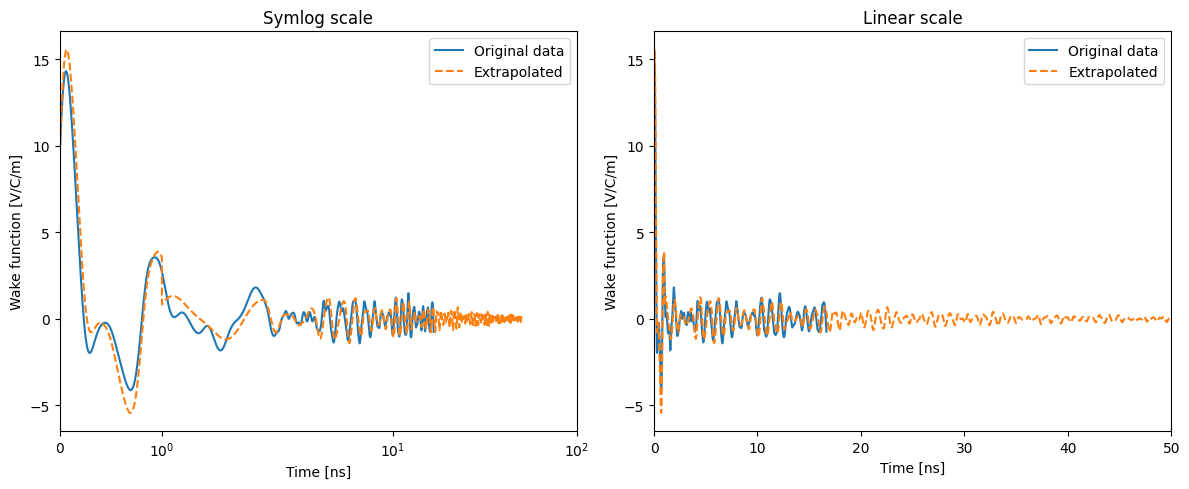

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot with symlog scale on the left
axs[0].plot(data_wake_time * 1e9, data_wake_dipolar, label="Original data")
axs[0].plot(time_ext * 1e9, total_wake_ext, label="Extrapolated", linestyle="--")
axs[0].set_xlabel("Time [ns]")
axs[0].set_ylabel("Wake function [V/C/m]")
axs[0].set_xscale("symlog")
axs[0].set_xlim(0, 100)
axs[0].title.set_text("Symlog scale")
axs[0].legend()

# Plot with linear scale until xlim(0,50) on the right
axs[1].plot(data_wake_time * 1e9, data_wake_dipolar, label="Original data")
axs[1].plot(time_ext * 1e9, total_wake_ext, label="Extrapolated", linestyle="--")
axs[1].set_xlabel("Time [ns]")
axs[1].set_ylabel("Wake function [V/C/m]")
axs[1].set_xlim(0, 50)
axs[1].title.set_text("Linear scale")
axs[1].legend()

plt.tight_layout()
plt.show()

In [16]:
plt.style.use(["ieee", "no-latex"])
fig, axs = plt.subplots(1, 1, figsize=(3, 1.75))

total_wake = DE_model.get_wake(time_ext) / c_light + data_wake_dipolar_1ns_padded
total_wake[0:3000] *= 0.9
# Plot with linear scale until xlim(0,50) on the right
axs.plot(time_ext * 1e9, total_wake, c="g", label="IDDEFIX extrapolated")
axs.plot(
    data_wake_time * 1e9,
    data_wake_dipolar,
    c="k",
    ls="-",
    label="CST simulated $W_{\perp y}$",
)
axs.set_xlabel("Time [ns]")
axs.set_ylabel("Wake function [V/C/m]")
axs.set_xlim(-1, 40)
axs.legend()

fig.tight_layout()
fig.savefig("output.pdf")

<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
/tmp/hschreib/ipykernel_230758/4268940167.py:13: SyntaxWarning: invalid escape sequence '\p'
  label="CST simulated $W_{\perp y}$",


OSError: 'ieee' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

### Impedance extrapolated

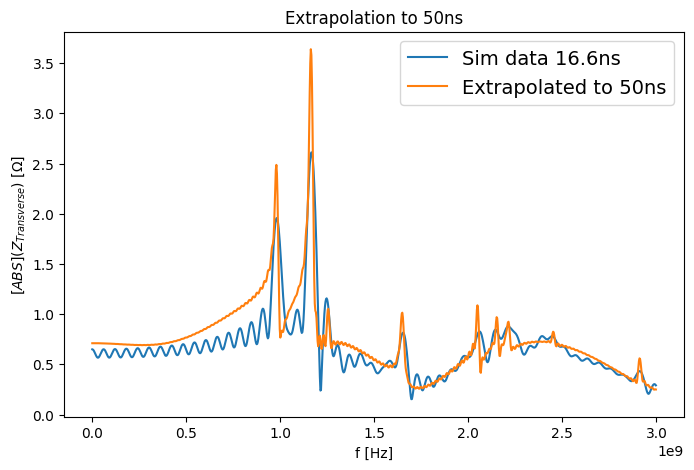

In [13]:
f_50ns, Z_50ns = iddefix.compute_fft(time_ext, total_wake_ext)

plt.figure(figsize=(8, 5))
plt.plot(f, np.abs(Z), label="Sim data 16.6ns")
plt.plot(f_50ns, np.abs(Z_50ns), label="Extrapolated to 50ns")
plt.legend()
plt.title("Extrapolation to 50ns")
plt.xlabel("f [Hz]")
plt.ylabel("$[ABS](Z_{Transverse})$ [$\Omega$]")
plt.legend(loc="best", fontsize=14)

ax0.set_xlim(0.1e9, 3e9)

ax0.grid()

### Using analytical wake and impedance from DE parameters

Another option, instead of extrapolating to a specific time, is to use the fully decayed wake and impedance functions in `iddefix`'s Resonator formalism

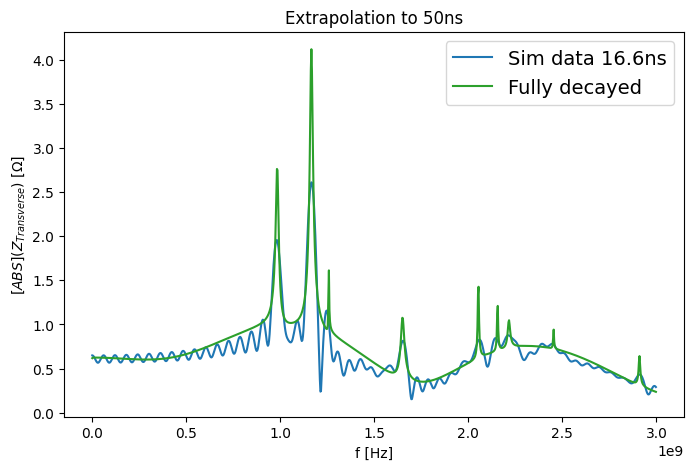

In [14]:
Z_fd = DE_model.get_impedance() + np.abs(Z_1ns)

# Compare magnitude [ABS]
plt.figure(figsize=(8, 5))
plt.plot(f, np.abs(Z), label="Sim data 16.6ns")
plt.plot(f, np.abs(Z_fd), color="tab:green", label="Fully decayed")
plt.legend()
plt.title("Extrapolation to 50ns")
plt.xlabel("f [Hz]")
plt.ylabel("$[ABS](Z_{Transverse})$ [$\Omega$]")
plt.legend(loc="best", fontsize=14)

ax0.set_xlim(0.1e9, 3e9)

ax0.grid()

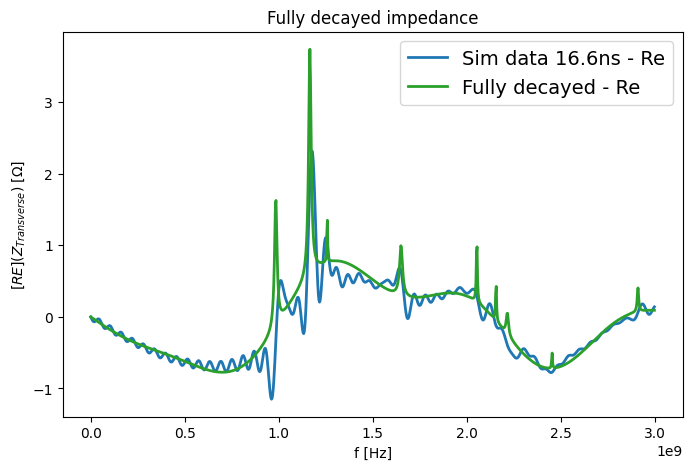

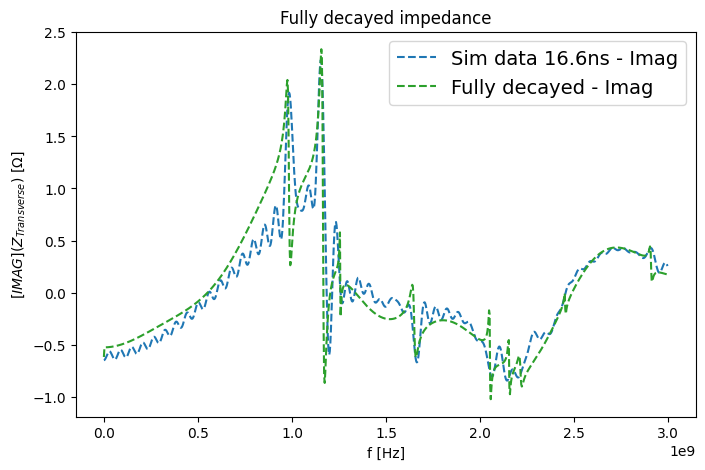

In [15]:
f, Z = iddefix.compute_fft(data_wake_time, data_wake_dipolar)
Z = -1j * Z  # Apply convention for transverse impedance to FFT
Z_fd = DE_model.get_impedance() - 1j * Z_1ns  # get_impedance() already applies the -1j

# Compare Re and Imag
plt.figure(figsize=(8, 5))
plt.plot(f, np.real(Z), c="tab:blue", lw=2, label="Sim data 16.6ns - Re")
plt.plot(f, np.real(Z_fd), c="tab:green", lw=2, label="Fully decayed - Re")
plt.legend()
plt.title("Fully decayed impedance")
plt.xlabel("f [Hz]")
plt.ylabel("$[RE](Z_{Transverse})$ [$\Omega$]")
plt.legend(loc="best", fontsize=14)
ax0.set_xlim(0.1e9, 3e9)
ax0.grid()

plt.figure(figsize=(8, 5))
plt.plot(f, np.imag(Z), ls="--", c="tab:blue", label="Sim data 16.6ns - Imag")
plt.plot(f, np.imag(Z_fd), c="tab:green", ls="--", label="Fully decayed - Imag")
plt.legend()
plt.title("Fully decayed impedance")
plt.xlabel("f [Hz]")
plt.ylabel("$[IMAG](Z_{Transverse})$ [$\Omega$]")
plt.legend(loc="best", fontsize=14)
ax0.set_xlim(0.1e9, 3e9)
ax0.grid()

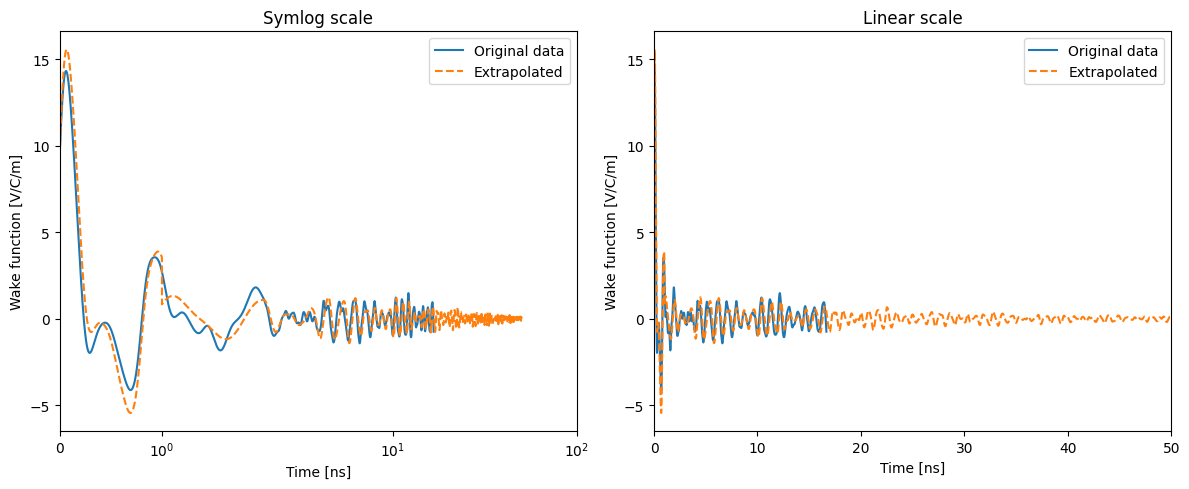

In [16]:
total_wake = DE_model.get_wake(time_ext) / c_light + data_wake_dipolar_1ns_padded

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot with symlog scale on the left
axs[0].plot(data_wake_time * 1e9, data_wake_dipolar, label="Original data")
axs[0].plot(time_ext * 1e9, total_wake, label="Extrapolated", linestyle="--")
axs[0].set_xlabel("Time [ns]")
axs[0].set_ylabel("Wake function [V/C/m]")
axs[0].set_xscale("symlog")
axs[0].set_xlim(0, 100)
axs[0].title.set_text("Symlog scale")
axs[0].legend()

# Plot with linear scale until xlim(0,50) on the right
axs[1].plot(data_wake_time * 1e9, data_wake_dipolar, label="Original data")
axs[1].plot(time_ext * 1e9, total_wake, label="Extrapolated", linestyle="--")
axs[1].set_xlabel("Time [ns]")
axs[1].set_ylabel("Wake function [V/C/m]")
axs[1].set_xlim(0, 50)
axs[1].title.set_text("Linear scale")
axs[1].legend()

plt.tight_layout()
plt.show()